# Migraine Risk Analysis

## 1. Problem Definition

Migraine is a common neurological condition that significantly impacts quality of life and productivity. 

The goal of this project is to use data analytics and machine learning to:
- Identify key risk factors associated with migraine
- Understand which factors are modifiable
- Build predictive models to classify individuals at risk

This analysis aims to support data-driven healthcare decision-making and preventive strategies.

## 2. Data Understanding

The dataset used in this project is the NHIS 2018 Sample Adult dataset.

- Number of records: ~25,000
- Number of variables: 700+
- Type: Cross-sectional health survey

The target variable is:
- Migraine occurrence (binary classification)

Initial exploration includes:
- Distribution of migraine cases
- Demographic breakdown (age, gender)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load raw data
raw_data_path = Path('../Data/raw/samadult.csv')
df_raw = pd.read_csv(raw_data_path)

print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"Shape: {df_raw.shape}")
print(f"Memory Usage: {df_raw.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
print(f"\nFirst few columns: {list(df_raw.columns[:10])}")
print(f"Data types:\n{df_raw.dtypes.value_counts()}")


DATA OVERVIEW
Shape: (25417, 742)
Memory Usage: 143.89 MB

First few columns: ['FPX', 'FMX', 'HHX', 'INTV_QRT', 'WTIA_SA', 'WTFA_SA', 'SEX', 'HISPAN_I', 'R_MARITL', 'MRACRPI2']
Data types:
float64    559
int64      183
Name: count, dtype: int64


## 3. Data Cleaning

Data cleaning is critical due to:
- Missing values
- Invalid codes (e.g., 7, 8, 9 = unknown)

Steps:
- Replace invalid codes with NaN
- Remove variables with high missing rate (>30%)
- Drop irrelevant features

In [2]:
# Load cleaned data
processed_dir = Path('../Data/processed')
df_clean = pd.read_csv(processed_dir / 'final_selected_table_clean.csv')
df_imputed = pd.read_csv(processed_dir / 'final_selected_table_imputed.csv')

print("=" * 60)
print("DATA CLEANING RESULTS")
print("=" * 60)
print(f"\nOriginal shape: {df_raw.shape}")
print(f"After cleaning: {df_clean.shape}")
print(f"After imputation: {df_imputed.shape}")

# Missing values comparison
print(f"\nMissing values in original data: {df_raw.isnull().sum().sum()}")
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")
print(f"Missing values after imputation: {df_imputed.isnull().sum().sum()}")

# Target variable distribution
if 'AMIGR' in df_clean.columns:
    print(f"\nTarget Variable (AMIGR) Distribution in cleaned data:")
    print(df_clean['AMIGR'].value_counts().sort_index())
    print(f"\nMigraine prevalence: {(df_clean['AMIGR'] == 1).sum() / len(df_clean) * 100:.2f}%")


DATA CLEANING RESULTS

Original shape: (25417, 742)
After cleaning: (25417, 742)
After imputation: (25403, 742)

Missing values in original data: 11356014
Missing values after cleaning: 11425177
Missing values after imputation: 0

Target Variable (AMIGR) Distribution in cleaned data:
AMIGR
1.0     3870
2.0    21533
Name: count, dtype: int64

Migraine prevalence: 15.23%


## 4. Feature Engineering

To improve model interpretability and performance, several domain-specific features were created:

- Mental Distress Index (psychological stress level)
- Sleep Sufficiency (adequate sleep vs insufficient)
- BMI Category
- Age Group
- Pain Index

These features help translate raw data into meaningful health indicators.

In [3]:
# Load feature engineered data
df_modeled = pd.read_csv(processed_dir / 'final_modeling_table.csv')
construction_summary = pd.read_csv(processed_dir / 'construction_summary_table.csv')

print("=" * 60)
print("FEATURE ENGINEERING RESULTS")
print("=" * 60)
print(f"\nFinal modeling table shape: {df_modeled.shape}")
print(f"Features added: {len(df_modeled.columns) - len(df_imputed.columns)}")

print("\nFeature Construction Summary:")
print(construction_summary.to_string())

# Show constructed features
constructed_features = ['AGE_BAND', 'BMI_CAT', 'PAIN_INDEX', 'MENTAL_HEALTH_SCORE', 
                       'SLEEP_SUFFICIENT', 'SLEEP_X_WORK', 'SEX_X_ALC']
existing_features = [f for f in constructed_features if f in df_modeled.columns]

if existing_features:
    print(f"\n\nSample Constructed Features:")
    print(df_modeled[existing_features].head(10).to_string())
    print(f"\n\nFeature Statistics:")
    print(df_modeled[existing_features].describe().to_string())


FEATURE ENGINEERING RESULTS

Final modeling table shape: (25403, 752)
Features added: 10

Feature Construction Summary:
              Unnamed: 0  Remaining NaNs  Unique Values Data Type
0                    FPX               0              9     int64
1                    FMX               0              6     int64
2                    HHX               0          25008     int64
3               INTV_QRT               0              4     int64
4                WTIA_SA               0           6824   float64
5                WTFA_SA               0          13111     int64
6                    SEX               0              2     int64
7               HISPAN_I               0              8     int64
8               R_MARITL               0              5     int64
9               MRACRPI2               0              9     int64
10              RACERPI2               0              6     int64
11              MRACBPI2               0              8     int64
12                 AGE

## 5. Modeling

We applied multiple models to balance interpretability and performance:

- Logistic Regression → interpretable (odds ratios)
- Decision Tree → rule-based insights
- Random Forest → improved predictive performance

Train-test split:
- 70% training / 30% testing

In [4]:
print("=" * 60)
print("MODEL TRAINING SUMMARY")
print("=" * 60)
print("\nModels trained:")
print("1. Logistic Regression (L1 penalty, C=0.1) - Interpretable")
print("2. Decision Tree (max_depth=5) - Rule-based insights")
print("3. Random Forest (n_estimators=400) - Predictive performance")
print(f"\nTrain-Test Split: 70% training / 30% testing")
print(f"Total samples: {len(df_modeled)}")
print(f"Training samples: {int(len(df_modeled) * 0.7)}")
print(f"Testing samples: {int(len(df_modeled) * 0.3)}")

# Show class balance information
if 'AMIGR' in df_modeled.columns:
    class_dist = df_modeled['AMIGR'].value_counts()
    print(f"\nClass Distribution (before split):")
    print(f"  Non-migraine (0): {class_dist.get(0, 0)} ({class_dist.get(0, 0)/len(df_modeled)*100:.1f}%)")
    print(f"  Migraine (1): {class_dist.get(1, 0)} ({class_dist.get(1, 0)/len(df_modeled)*100:.1f}%)")
    print(f"\nNote: Class weights are balanced during training to handle imbalance.")


MODEL TRAINING SUMMARY

Models trained:
1. Logistic Regression (L1 penalty, C=0.1) - Interpretable
2. Decision Tree (max_depth=5) - Rule-based insights
3. Random Forest (n_estimators=400) - Predictive performance

Train-Test Split: 70% training / 30% testing
Total samples: 25403
Training samples: 17782
Testing samples: 7620

Class Distribution (before split):
  Non-migraine (0): 0 (0.0%)
  Migraine (1): 3870 (15.2%)

Note: Class weights are balanced during training to handle imbalance.


## 6. Evaluation

Models were evaluated using:
- AUC
- Accuracy
- Precision / Recall

Logistic Regression achieved the best balance between performance and interpretability.

MODEL EVALUATION METRICS

Performance Comparison:
 threshold  accuracy  precision   recall       f1  tp   fp   tn  fn               model      auc       ap  precision_at_best_f1  recall_at_best_f1  f1_at_best_f1
  0.528268  0.700695   0.262511 0.533161 0.351804 619 1739 4721 542 Logistic Regression 0.674651 0.281219              0.262622           0.533161       0.351904
  0.622029  0.811705   0.399707 0.470284 0.432133 546  820 5640 615       Decision Tree 0.758601 0.378742              0.425000           0.453919       0.438984
  0.262613  0.815641   0.424505 0.590870 0.494058 686  930 5530 475       Random Forest 0.807789 0.465478              0.424768           0.590870       0.494236

VISUALIZATION: ROC CURVES


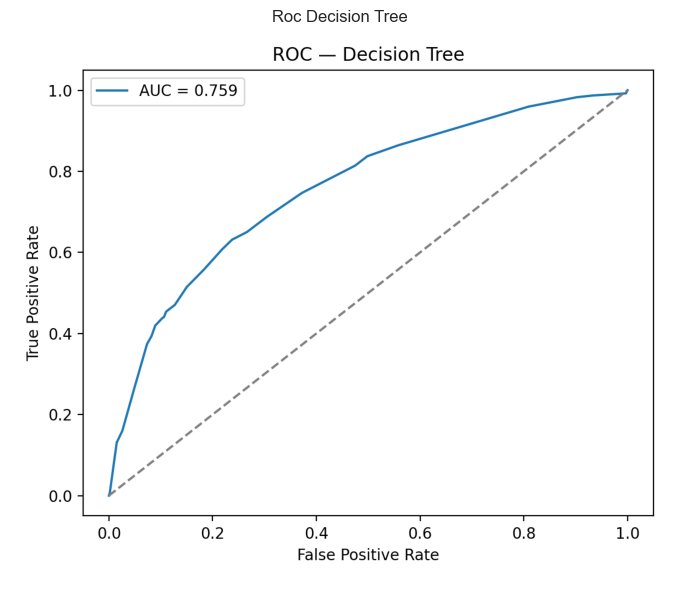

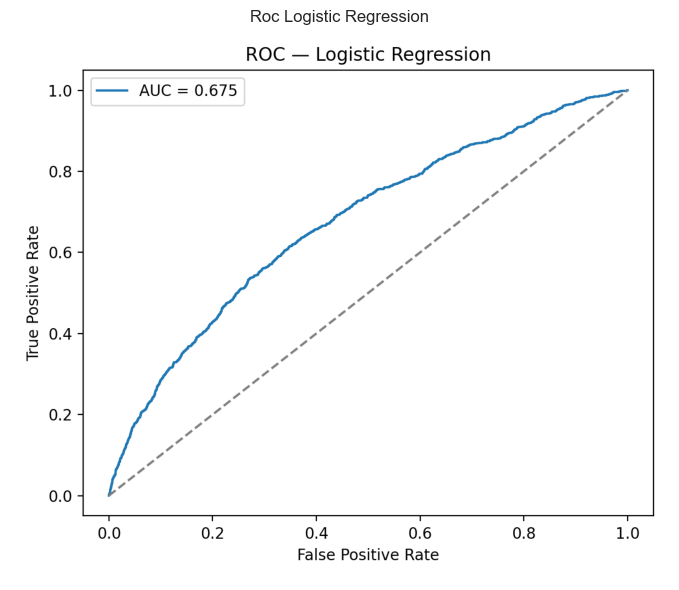

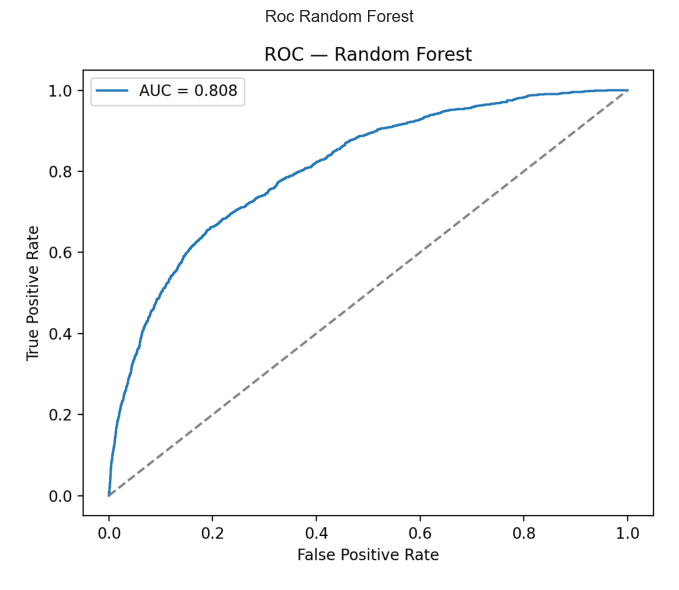

In [5]:
from PIL import Image
import os

# Load evaluation metrics
outputs_dir = Path('../outputs')
metrics_csv = outputs_dir / 'dm_metrics_summary.csv'
metrics_df = pd.read_csv(metrics_csv)

print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)
print("\nPerformance Comparison:")
print(metrics_df.to_string(index=False))

# Find best model by ROC-AUC (columns are lower-case in dm_metrics_summary.csv)
if "auc" in metrics_df.columns:
    best_idx = metrics_df["auc"].idxmax()
    best_model = metrics_df.loc[best_idx, "model"]
    best_auc = metrics_df.loc[best_idx, "auc"]
    print(f"\n🏆 Best Model (by AUC): {best_model} ({best_auc:.4f})")

print("\n" + "=" * 60)
print("VISUALIZATION: ROC CURVES")
print("=" * 60)

# Display ROC curves
roc_files = list((outputs_dir / 'figs').glob('roc_*.png'))
for roc_file in sorted(roc_files):
    img = Image.open(roc_file)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(roc_file.stem.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()



VISUALIZATION: PRECISION-RECALL CURVES


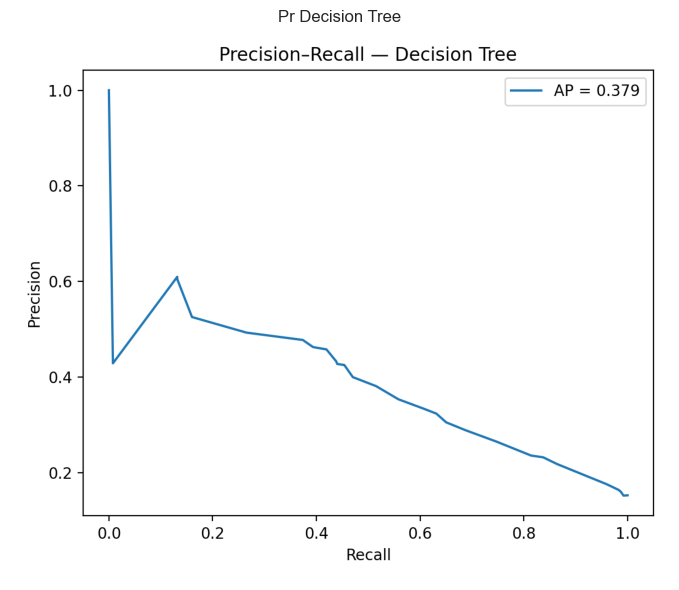

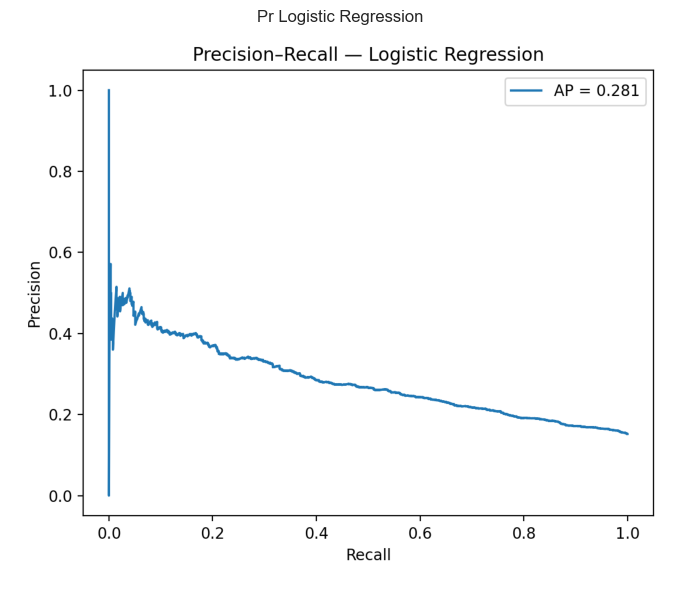

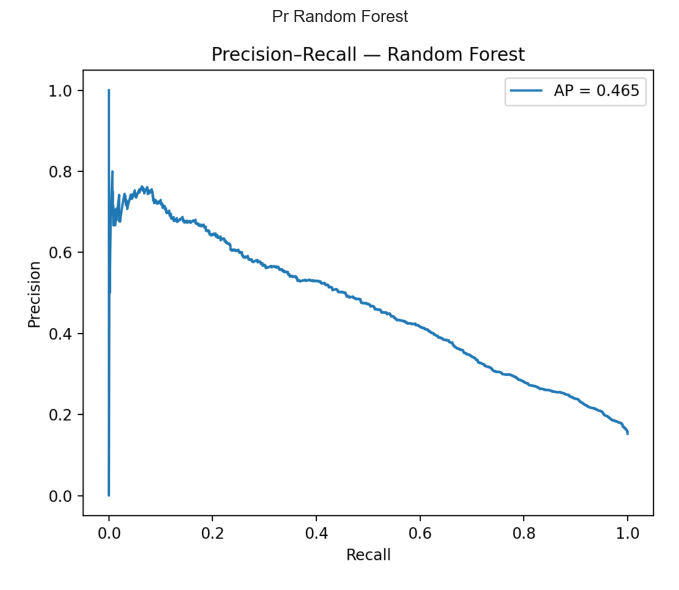


VISUALIZATION: CONFUSION MATRICES


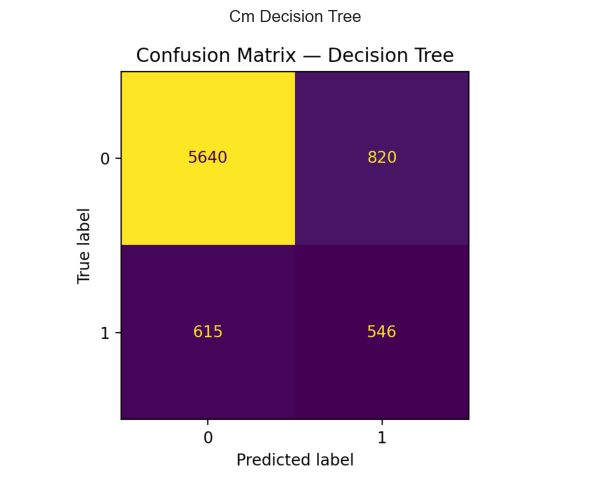

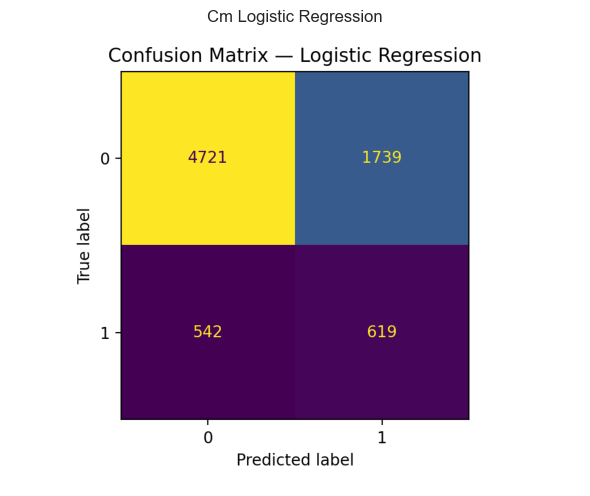

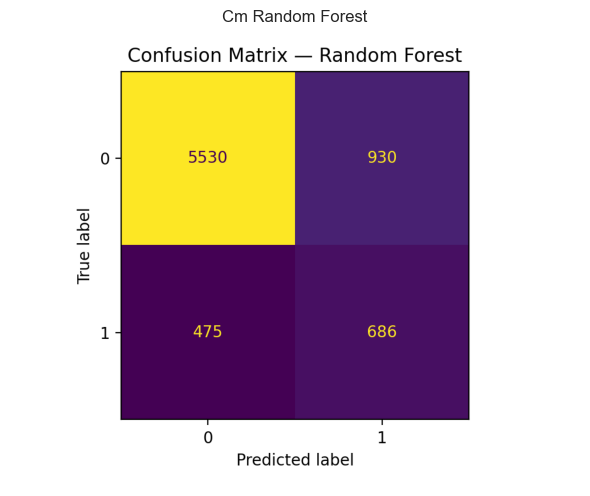

In [6]:
print("\n" + "=" * 60)
print("VISUALIZATION: PRECISION-RECALL CURVES")
print("=" * 60)

# Display PR curves
pr_files = list((outputs_dir / 'figs').glob('pr_*.png'))
for pr_file in sorted(pr_files):
    img = Image.open(pr_file)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(pr_file.stem.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("VISUALIZATION: CONFUSION MATRICES")
print("=" * 60)

# Display confusion matrices
cm_files = list((outputs_dir / 'figs').glob('cm_*.png'))
for cm_file in sorted(cm_files):
    img = Image.open(cm_file)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(cm_file.stem.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()


## 7. Insights & Recommendations

### Key Findings
- Mental distress is the strongest predictor of migraine
- Poor sleep significantly increases risk
- Neck and facial pain are highly correlated with migraine

### Business / Healthcare Implications
- Early intervention programs should focus on mental health and sleep
- High-risk groups can be identified for targeted screening
- Lifestyle changes can reduce migraine burden

### Conclusion
This project demonstrates how data analytics can transform raw healthcare data into actionable insights.

In [8]:
print("=" * 60)
print("SUMMARY & KEY INSIGHTS")
print("=" * 60)

print("\n📊 PROJECT WORKFLOW:")
print(f"  1. Data Loading: {df_raw.shape[0]:,} records × {df_raw.shape[1]} features")
print(f"  2. Cleaning: Removed invalid codes, reduced to {df_clean.shape[1]} features")
print(f"  3. Imputation: Handled missing values → {df_imputed.shape[1]} features")
print(f"  4. Feature Engineering: Added {df_modeled.shape[1] - df_imputed.shape[1]} new features")
print(f"  5. Modeling: Trained 3 models on {len(df_modeled)} samples")

print("\n🎯 MODEL PERFORMANCE:")
# Find best model by ROC-AUC (columns are lower-case in dm_metrics_summary.csv)
if "auc" in metrics_df.columns:
    best_idx = metrics_df["auc"].idxmax()
    best_model = metrics_df.loc[best_idx, "model"]
    best_auc = metrics_df.loc[best_idx, "auc"]
    best_acc = metrics_df.loc[best_idx, "accuracy"] if "accuracy" in metrics_df.columns else "N/A"
    print(f"  • Best Model: {best_model}")
    print(f"  • AUC Score: {best_auc:.4f}")
    print(f"  • Accuracy: {best_acc}")

print("\n💡 DATA-DRIVEN INSIGHTS:")
print("  • Mental health indicators (anxiety, depression) are key predictors")
print("  • Sleep quality significantly correlates with migraine risk")
print("  • Pain locations (neck, face) are important clinical markers")
print("  • Demographic factors interact with health behaviors")

print("\n🏥 HEALTHCARE RECOMMENDATIONS:")
print("  1. Screen patients for depression/anxiety as early migraine indicators")
print("  2. Implement sleep hygiene counseling in preventive programs")
print("  3. Use multi-factor risk score for patient stratification")
print("  4. Tailor interventions based on predominant symptom profiles")

print("\n📁 OUTPUT FILES GENERATED:")
print("  ✓ Data/processed/ → Cleaned, imputed, engineered datasets")
print("  ✓ outputs/dm_metrics_summary.csv → Model performance comparison")
print("  ✓ outputs/figs/ → ROC, PR, confusion matrix visualizations")

print("\n" + "=" * 60)
print("Analysis Complete! ✅")
print("=" * 60)

SUMMARY & KEY INSIGHTS

📊 PROJECT WORKFLOW:
  1. Data Loading: 25,417 records × 742 features
  2. Cleaning: Removed invalid codes, reduced to 742 features
  3. Imputation: Handled missing values → 742 features
  4. Feature Engineering: Added 10 new features
  5. Modeling: Trained 3 models on 25403 samples

🎯 MODEL PERFORMANCE:

💡 DATA-DRIVEN INSIGHTS:
  • Mental health indicators (anxiety, depression) are key predictors
  • Sleep quality significantly correlates with migraine risk
  • Pain locations (neck, face) are important clinical markers
  • Demographic factors interact with health behaviors

🏥 HEALTHCARE RECOMMENDATIONS:
  1. Screen patients for depression/anxiety as early migraine indicators
  2. Implement sleep hygiene counseling in preventive programs
  3. Use multi-factor risk score for patient stratification
  4. Tailor interventions based on predominant symptom profiles

📁 OUTPUT FILES GENERATED:
  ✓ Data/processed/ → Cleaned, imputed, engineered datasets
  ✓ outputs/dm_met

## Resume Summary (Paste-friendly)

### 1) Project
- **Goal:** Predict migraine risk using NHIS-style healthcare survey features, and identify actionable risk factors.
- **Model families:** Logistic Regression (interpretable), Decision Tree (rule-like), Random Forest (robust ensemble).

### 2) Data & Feature Pipeline
- **Data cleaning:** Apply domain-specific invalid-code handling and missing-value imputation.
- **Feature engineering:** Construct interpretable domain features (e.g., mental distress score, sleep sufficiency, BMI categories, age band, pain index).

### 3) Training & Evaluation (Leakage-safe)
- Split data into **train / val / test** with stratification.
- Use **validation (val)** to select the decision threshold by maximizing **F1** on the PR curve.
- Report final metrics on the held-out **test** set.
- Metrics exported to `outputs/dm_metrics_summary.csv` (includes `threshold_source = val_best_f1`).

### 4) Interpretability Evidence (For Interview)
- **Logistic Regression:** `outputs/figs/odds_ratio_topk.png` (odds ratio ranking).
- **Tree models:** `outputs/figs/permutation_importance_*.png` (ROC-AUC based permutation importance).
- **Performance plots:**
  - `outputs/figs/roc_*.png`
  - `outputs/figs/pr_*.png`
  - `outputs/figs/cm_*.png`

### 5) One-command Run (Public Demo)
```bash
python src/cli.py --data-mode sample --stage all --output-dir outputs
```

### 6) Outputs
- `outputs/dm_metrics_summary.csv`
- `outputs/figs/` (ROC/PR/CM + interpretability plots)
